# SV parallelism vs climate — does the SV excess open at hot / arid sites?

Uses the ~10-12 replicate **plots** within each site as parallel populations (same founding + climate;
each an independent pool-seq -> independent allele-frequency change). Consistency across replicate
plots = drift control. Parallelism rho = mean^2/mean(slope^2) across plots (AF-vapeR rank-1 eigenvalue
analog; 0 = drift, 1 = fully parallel), frequency-matched SV vs SNP.

**Why only this section.** The replicate arm originally had three: bulk parallelism, PicMin, and this
climate gradient. On post-Kf_w data the first two came out at or near parity (bulk 1.0-1.3x and n.s. at
mid/common MAF; PicMin ~1.1x), and PicMin is direction-agnostic besides -- its per-locus input is |z|,
so a purged variant and a swept one score alike. Both were archived 2026-08-25
(`../r1_sv_negative_selection/archive/replicate_arm_bulk_2026-08-25/`). This section is the piece that
survived the fix and speaks to the headline.

> **Standing caveats (unchanged).** Global-mode kMate AF is a founder projection, so this cannot
> separate SV-specific selection from hitchhiking on a climate-purged haplotype; the insertion signal
> is not ancestrally polarized. See `SV_TEMPORAL_PURGING_SUMMARY.md`.
>
> **Not yet de-trended.** "Survived" here means unchanged by the Kf_w fix -- NOT that it survives the
> per-p0-bin SNP-median subtraction that nulled the whole-distribution median shift. Its sibling arm
> (climate-slope beta sign-excess) did get that test and weakened to borderline (p=0.013 -> 0.050).
> Treat this arm's numbers as one evidentiary tier below the tail-gap result until the same test is run.


## 3. Per-site parallelism vs climate — does the SV excess open at hot / arid sites?

For each site, the ECDF-difference of ρ (SV vs frequency-matched SNP): a positive hump = SVs shifted to
higher ρ (more parallel/selected) than same-frequency SNPs at that site. Small multiples ordered/coloured
cold→hot (bio1); then the per-site SV−SNP mean-ρ excess regressed on bio1 and bio18. **This
climate-gradient of the excess is the piece that survived the Kf_w fix.**

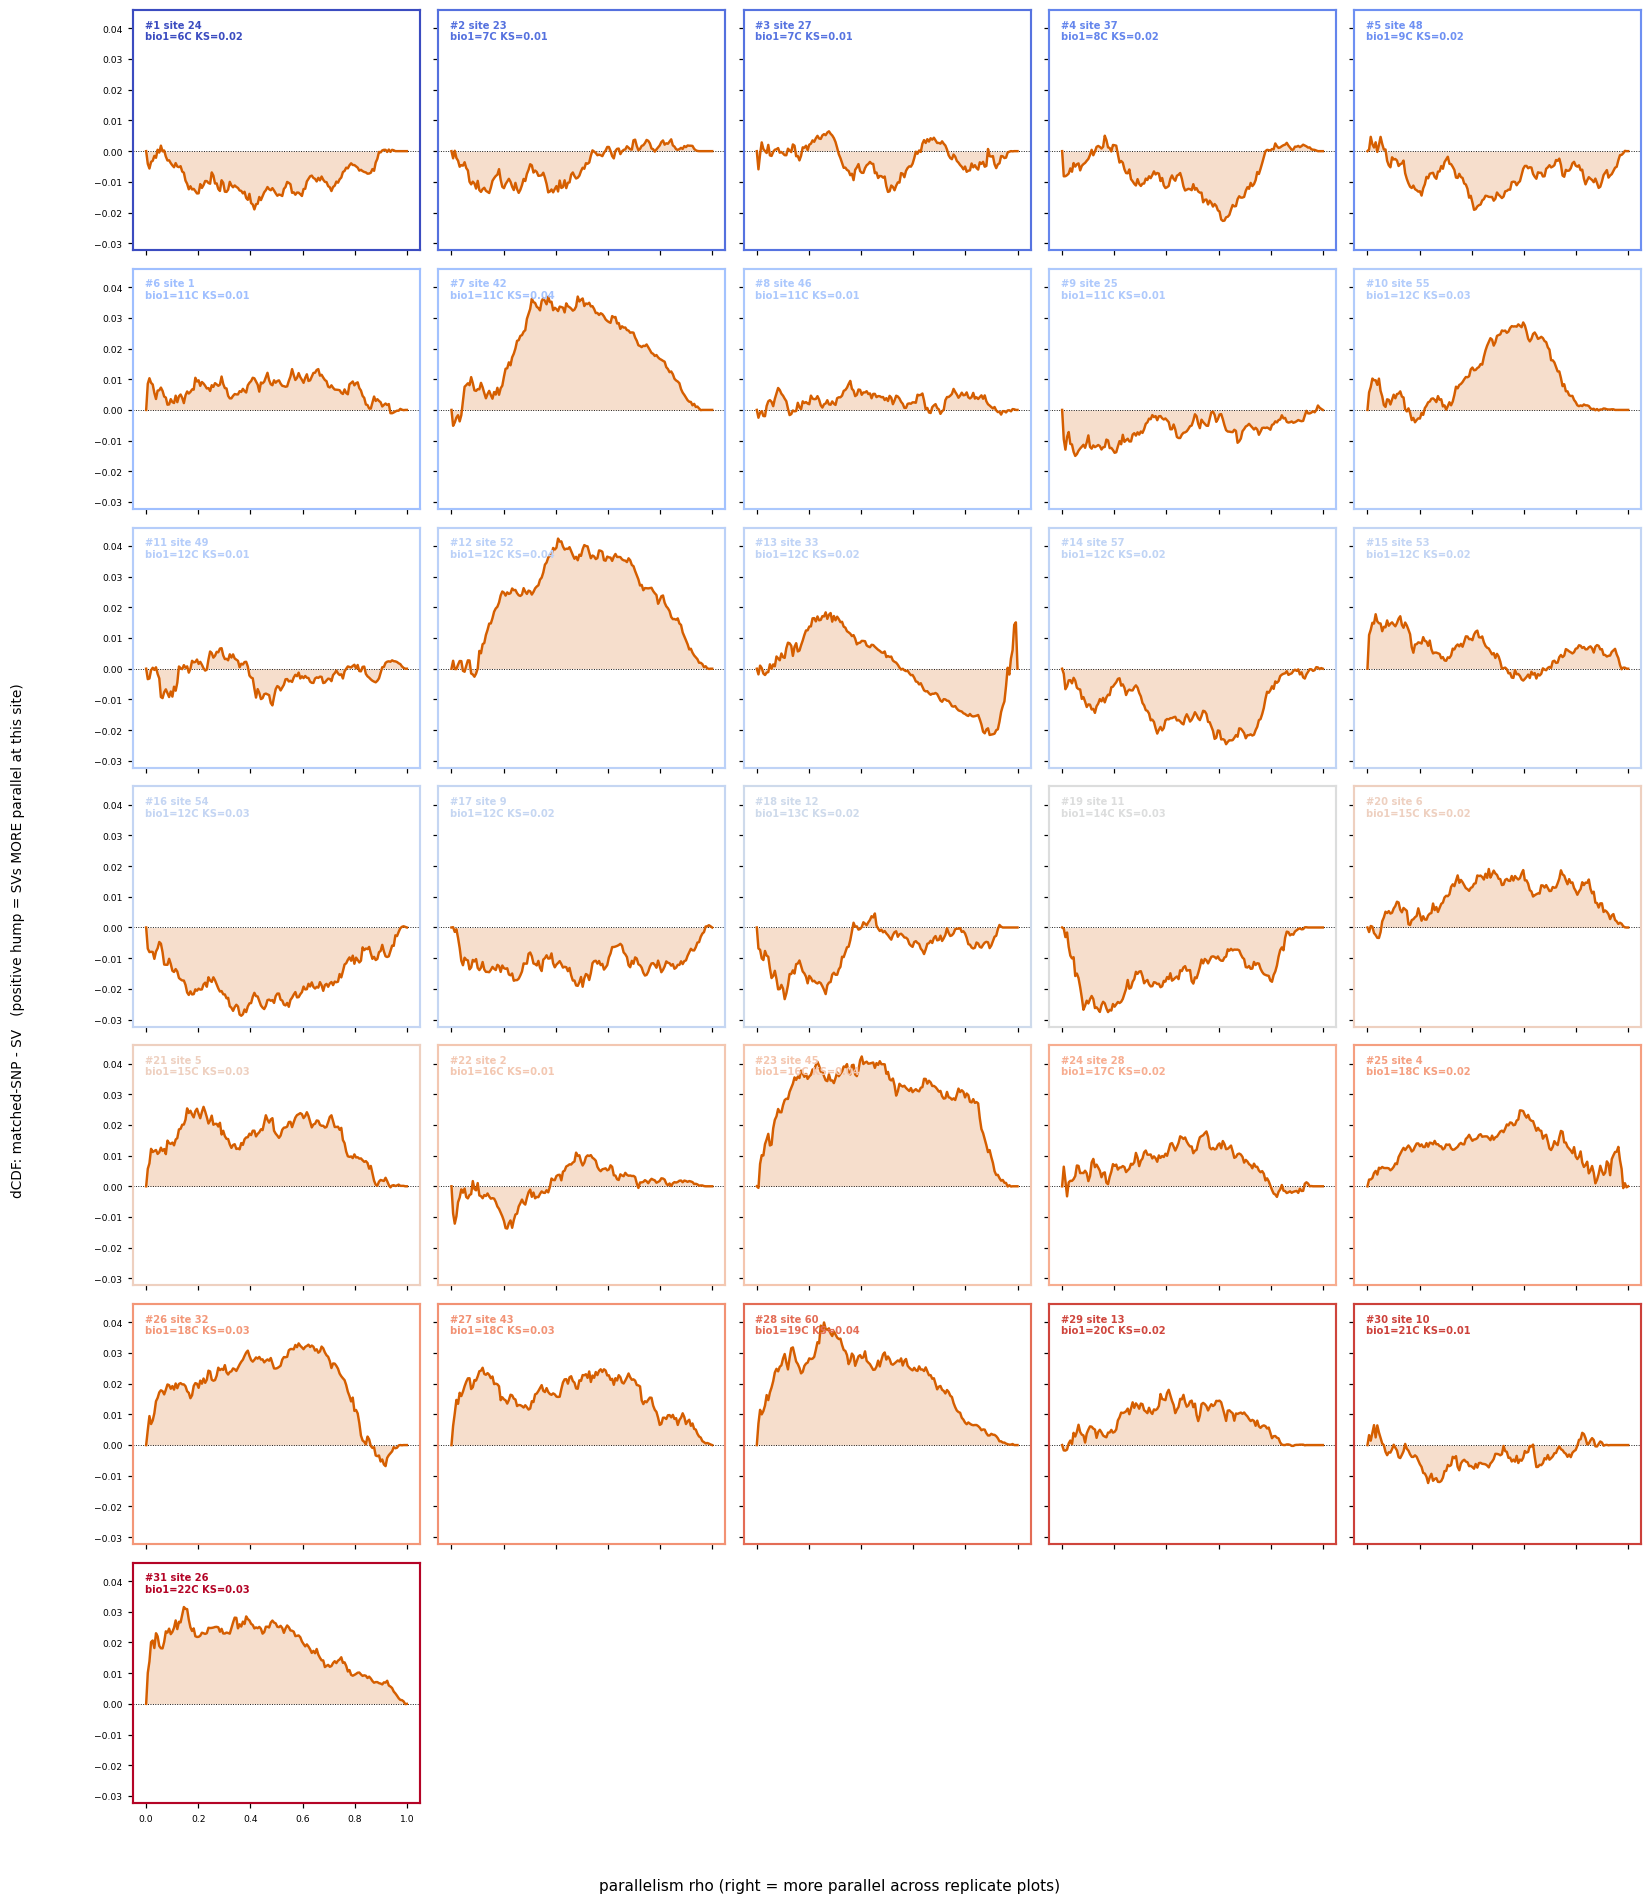

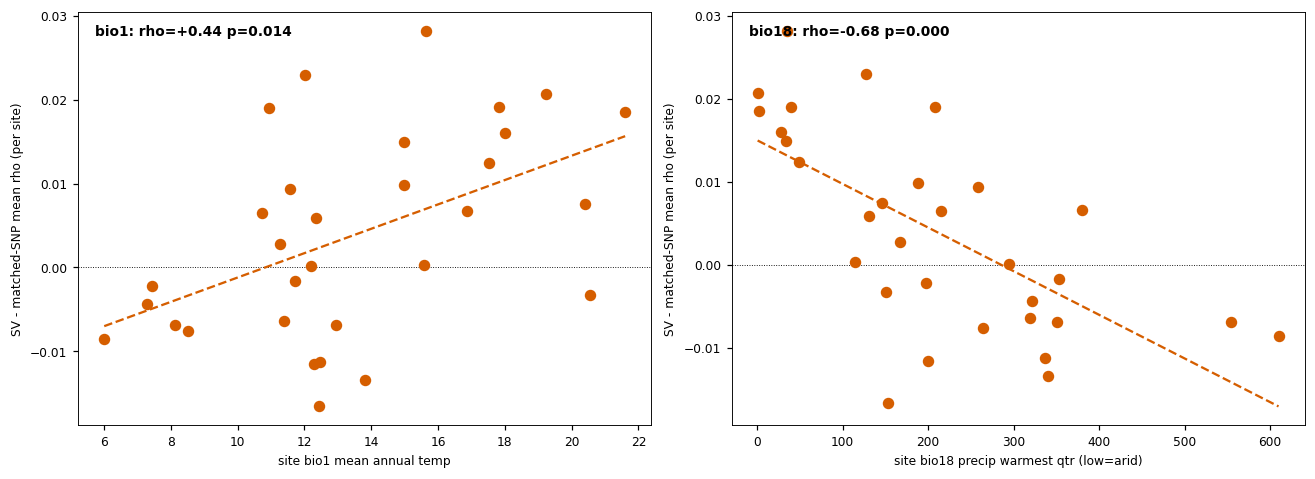

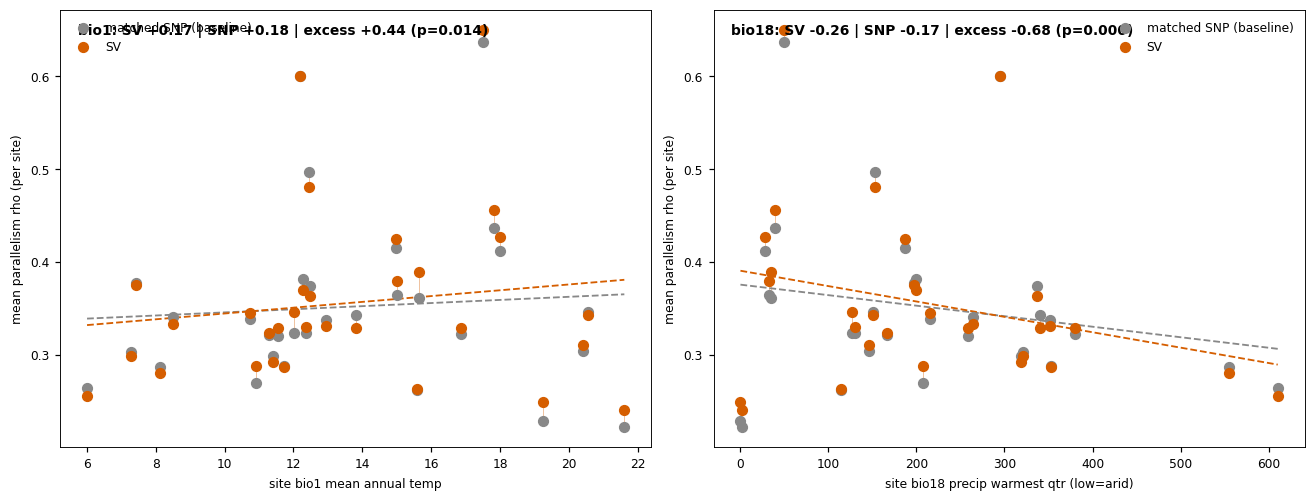

SV mean-rho: corr bio1 +0.17; matched-SNP baseline corr bio1 +0.18
SV mean-rho: corr bio18 -0.26; matched-SNP baseline corr bio18 -0.17
EXCESS (SV-SNP): corr bio1 +0.44 (p=0.014); bio18 -0.68 (p=0.000)


In [1]:

import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
plt.rcParams.update({'figure.dpi':110,'font.size':8,'axes.linewidth':0.6})
G="/global/scratch/users/tbellg/kmate/analysis/grenenet_selection/r1_sv_negative_selection/results/sv_adaptive"
z=np.load(f"{G}/parallelism.npz"); rng=np.random.default_rng(0)
RSV=z["rhops_sv"]; RSN=z["rhops_snp"]; p0sv=z["p0_sv"]; p0sn=z["p0_snp"]
b1=z["site_bio1"]; b18=z["site_bio18"]; sites=z["used_sites"]
order=np.argsort(b1)                                  # cold -> hot
GRID=np.linspace(0,1,160)
def match_idx(tp0,sp0):
    e=np.quantile(np.concatenate([tp0,sp0]),np.linspace(0,1,26)); e[-1]+=1e-9
    tb=np.digitize(tp0,e[1:-1]); sb=np.digitize(sp0,e[1:-1]); idx=[]
    for k in range(25):
        pool=np.where(sb==k)[0]; nn=int(round((tb==k).mean()*15000))
        if nn and pool.size: idx.append(rng.choice(pool,nn,replace=True))
    return np.concatenate(idx)
MI=match_idx(p0sv,p0sn)                                # fixed matched-SNP index set (same each site)
cdf=lambda s:np.searchsorted(np.sort(s),GRID,side="right")/s.size

ncol,nrow=5,int(np.ceil(len(order)/5)); norm=mpl.colors.Normalize(b1.min(),b1.max()); cmap=mpl.cm.coolwarm
fig,axes=plt.subplots(nrow,ncol,figsize=(15,2.5*nrow),sharex=True,sharey=True); axes=axes.ravel()
for ax in axes[len(order):]: ax.axis("off")
exv=np.zeros(len(sites))                               # per-column SV mean-rho excess
for i,c in enumerate(order):
    ax=axes[i]; dd=cdf(RSN[MI,c])-cdf(RSV[:,c])       # pos = SV shifted to higher rho (more parallel)
    ax.axhline(0,color="k",lw=.6,ls=":")
    ax.fill_between(GRID,0,dd,color="#D55E00",alpha=.2,lw=0); ax.plot(GRID,dd,color="#D55E00",lw=1.6)
    exv[c]=RSV[:,c].mean()-RSN[MI,c].mean()
    col=cmap(norm(b1[c]))
    ax.annotate(f"#{i+1} site {int(sites[c])}\nbio1={b1[c]:.0f}C KS={np.abs(dd).max():.02f}",
                xy=(0.04,0.96),xycoords="axes fraction",va="top",ha="left",fontsize=6.5,color=col,fontweight="bold")
    for sp in ax.spines.values(): sp.set_color(col); sp.set_linewidth(1.4)
    ax.tick_params(labelsize=6)
fig.supxlabel("parallelism rho (right = more parallel across replicate plots)",y=0.005,fontsize=10)
fig.supylabel("dCDF: matched-SNP - SV   (positive hump = SVs MORE parallel at this site)",x=0.004,fontsize=9)
fig.tight_layout(rect=[0.03,0.02,1,0.99]); fig.savefig(f"{G}/plots/parallelism_by_site.png",dpi=130,bbox_inches="tight"); plt.show()

# excess-only (SV - matched-SNP) per site vs climate
figA,axA=plt.subplots(1,2,figsize=(12,4.4))
def corner(ax,txt): ax.annotate(txt,xy=(0.03,0.97),xycoords="axes fraction",va="top",ha="left",fontsize=9,fontweight="bold")
for a,(cv,lab) in zip(axA,[(b1,"bio1 mean annual temp"),(b18,"bio18 precip warmest qtr (low=arid)")]):
    a.axhline(0,color="k",lw=.6,ls=":"); a.scatter(cv,exv,c="#D55E00",s=42,zorder=3)
    m,c0=np.polyfit(cv,exv,1); xs=np.array([cv.min(),cv.max()]); a.plot(xs,c0+m*xs,color="#D55E00",ls="--")
    r=stats.spearmanr(cv,exv); a.set_xlabel(f"site {lab}"); a.set_ylabel("SV - matched-SNP mean rho (per site)")
    corner(a,f"{lab.split()[0]}: rho={r.statistic:+.2f} p={r.pvalue:.3f}")
figA.tight_layout(); figA.savefig(f"{G}/plots/parallelism_by_site_excess.png",dpi=130,bbox_inches="tight"); plt.show()

# both series (SV + matched-SNP baseline) + the gap
sv_mean=np.array([RSV[:,c].mean() for c in range(len(sites))])
sn_mean=np.array([RSN[MI,c].mean() for c in range(len(sites))])
fig2,ax2=plt.subplots(1,2,figsize=(12,4.6))
for a,(cv,lab) in zip(ax2,[(b1,"bio1 mean annual temp"),(b18,"bio18 precip warmest qtr (low=arid)")]):
    for x,lo,hi in zip(cv,sn_mean,sv_mean):
        a.plot([x,x],[lo,hi],color="#D55E00",lw=0.6,alpha=0.4,zorder=2)      # gap = SV excess
    a.scatter(cv,sn_mean,c="#888888",s=40,zorder=3,label="matched SNP (baseline)")
    a.scatter(cv,sv_mean,c="#D55E00",s=40,zorder=3,label="SV")
    for yy,col in [(sn_mean,"#888888"),(sv_mean,"#D55E00")]:
        m,c0=np.polyfit(cv,yy,1); xs=np.array([cv.min(),cv.max()]); a.plot(xs,c0+m*xs,color=col,ls="--",lw=1.2)
    rS=stats.spearmanr(cv,sv_mean); rN=stats.spearmanr(cv,sn_mean); rE=stats.spearmanr(cv,sv_mean-sn_mean)
    a.set_xlabel(f"site {lab}"); a.set_ylabel("mean parallelism rho (per site)")
    corner(a,f"{lab.split()[0]}: SV {rS.statistic:+.2f} | SNP {rN.statistic:+.2f} | excess {rE.statistic:+.2f} (p={rE.pvalue:.3f})")
    a.legend(frameon=False,fontsize=8)
fig2.tight_layout(); fig2.savefig(f"{G}/plots/parallelism_by_site_summary.png",dpi=130,bbox_inches="tight"); plt.show()
print(f"SV mean-rho: corr bio1 {stats.spearmanr(b1,sv_mean).statistic:+.2f}; matched-SNP baseline corr bio1 {stats.spearmanr(b1,sn_mean).statistic:+.2f}")
print(f"SV mean-rho: corr bio18 {stats.spearmanr(b18,sv_mean).statistic:+.2f}; matched-SNP baseline corr bio18 {stats.spearmanr(b18,sn_mean).statistic:+.2f}")
print(f"EXCESS (SV-SNP): corr bio1 {stats.spearmanr(b1,sv_mean-sn_mean).statistic:+.2f} (p={stats.spearmanr(b1,sv_mean-sn_mean).pvalue:.3f}); "
      f"bio18 {stats.spearmanr(b18,sv_mean-sn_mean).statistic:+.2f} (p={stats.spearmanr(b18,sv_mean-sn_mean).pvalue:.3f})")


### Takeaway
The per-site SV-minus-matched-SNP parallelism excess is **climate-graded**: the gap opens toward hot /
arid sites (bio1 +0.44 p=0.014, bio18 -0.68 p=0.000), while the matched-SNP baseline parallelism is
~flat. This mirrors the climate-slope beta arm through an independent statistic -- replicate-plot
parallelism rather than a per-variant trajectory slope -- with aridity dominant in both.

It is corroboration, not independent proof: both arms read the same global-mode founder projection, so
they share the hitchhiking caveat rather than resolving it between them.
